Total Received : 32832 Bytes.
Header_Length :  64
Header_Data :  [64.0, 32768.0, 1.0, 1.0, 512.0, 0.0, 1953125.0, 12.0, 0.0, 0.0, 0.33564960956573486, 0.0, 0.0, 0.2199999988079071, 0.0, 0.0]
Ultrasonic Data Length :  32768
16400
Length of Header : 16
Length of Ultrasonic Data : 16384


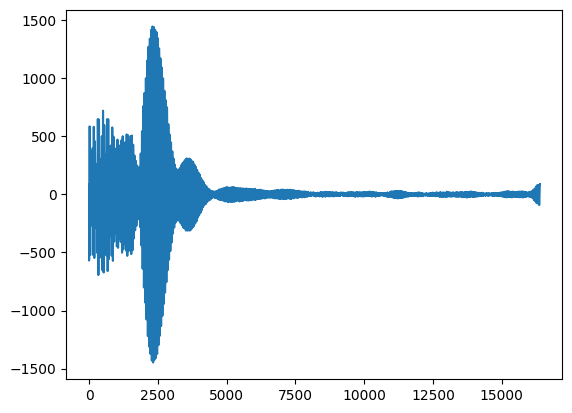

In [7]:
import socket
import struct





buffer_size = 65536

msg_from_client = "-a 1"

bytes_to_send = str.encode(msg_from_client)

server_address_port = ("192.168.128.1", 61231)


# Create a UDP socket at client side
udp_client_socket = socket.socket(family=socket.AF_INET, type=socket.SOCK_DGRAM)

# Send to server using created UDP socket

udp_client_socket.sendto(bytes_to_send, server_address_port)

packet = udp_client_socket.recv(buffer_size)

print(f"Total Received : {len(packet)} Bytes.")



header_length = int(struct.unpack('@f', packet[:4])[0])
ultrasonic_data_length = int(struct.unpack('@f', packet[4:8])[0])


header_data = []
for i in struct.iter_unpack('@f', packet[:header_length]):
    header_data.append(i[0])

print("Header_Length : ", header_length)
print("Header_Data : ", header_data)


ultrasonic_data = []
for i in struct.iter_unpack('@h', packet[header_length:]):
    ultrasonic_data.append(i[0])

print("Ultrasonic Data Length : ", ultrasonic_data_length)
# print("Ultrasonic Data : ", ultrasonic_data)

print(len(ultrasonic_data) + len(header_data))

print(f"Length of Header : {len(header_data)}")
print(f"Length of Ultrasonic Data : {len(ultrasonic_data)}")

udp_client_socket.close()

import matplotlib.pyplot as plt

plt.plot(ultrasonic_data)

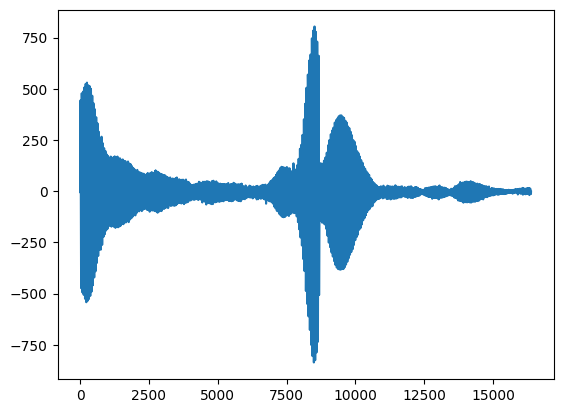

In [6]:
import matplotlib.pyplot as plt

plt.plot(ultrasonic_data)

### Segment the data (divide it into frames) - to avoid information loss, the frames should overlap.
### In each frame, apply a window function (Hann, Hamming, Blackman etc) - to minimize discontinuities at the beginning and end.

In [4]:
import numpy as np
raw_adc_array = np.array(ultrasonic_data)

In [5]:
raw_adc_array

array([  47,   39, -211, ...,   63,   58,   52])

In [10]:
indices = [i*100 for i in range(1,164)]

#### Splitting into non overlapping segments of 100 data value in each array segment

In [ ]:

np.split(raw_adc_array, indices)

In [23]:

type(np.split(raw_adc_array, indices))

list

#### Splitting into overlapping segments of 50 percent

In [15]:
164 + 164/2

246.0

In [ ]:
frame_size = 100
start_index = 0
for i in range(328):
    # print(raw_adc_array[start_index:start_index + frame_size])
    start_index = int(( start_index + start_index + frame_size ) / 2) # overlap of 50%
    print(start_index)
    # plt.plot(raw_adc_array[start_index:start_index + frame_size])
    # plt.show()
    

In [19]:
16384/50

327.68

In [80]:
def get_arrays_with_overlap_percent(original_array, overlap_percentage=50, single_segment_size=10):
    len_of_org_array = len(original_array)
    range_of_overlap_array = int(len_of_org_array / (overlap_percentage * single_segment_size/100))
    print(range_of_overlap_array)
    overlapped_arrays = list()
    start_index = 0
    for i in range(range_of_overlap_array):
        print(start_index)
        overlapped_arrays.append(np.array(original_array[start_index:start_index + single_segment_size]))
        start_index = int(start_index +  ((100 - overlap_percentage)* single_segment_size)/100)
    return overlapped_arrays    

In [88]:
import math


def get_arrays_with_overlap_percent2(original_array, overlap_percentage=50, single_segment_size=100):
    len_of_org_array = len(original_array)
    print("Length of original array : ", len_of_org_array)
    # print("Value for first non-overlapped : " , (len_of_org_array / single_segment_size))
    # print("Value added by overlapping : ", (overlap_percentage * single_segment_size / 100))
    non_overlapped_len = len_of_org_array / single_segment_size
    overlapped_len = (100 - overlap_percentage) * non_overlapped_len / 100
    
    
    overlap_size = overlap_percentage * single_segment_size / 100
    
    range_of_overlap_array = math.ceil((len_of_org_array - overlap_size) / (single_segment_size - overlap_size))
    
    # range_of_overlap_array = int(non_overlapped_len + overlapped_len)
    # print(((len_of_org_array / single_segment_size) + ((100 - overlap_percentage) * (len_of_org_array / single_segment_size) / 100)))
    # range_of_overlap_array = int((len_of_org_array / single_segment_size) + ((100 - overlap_percentage) * (len_of_org_array / single_segment_size) / 100))
    # print(non_overlapped_len)
    # print(overlapped_len)
    print(range_of_overlap_array)
    
    overlapped_arrays = list()
    start_index = 0
    for i in range(range_of_overlap_array):
        print(start_index)
        overlapped_arrays.append(np.array(original_array[start_index:start_index + single_segment_size]))
        start_index = int(start_index +  ((100 - overlap_percentage)* single_segment_size)/100)
    return overlapped_arrays    

In [9]:
arr1 = list(range(100))
# get_arrays_with_overlap_percent2(arr1, overlap_percentage=30)

In [8]:
import math
import numpy as np


def get_arrays_with_overlap_percent(original_array, overlap_percentage=50, single_segment_size=100):
    len_of_org_array = len(original_array)
    overlap_size = overlap_percentage * single_segment_size / 100
    range_of_overlap_array = math.ceil((len_of_org_array - overlap_size) / (single_segment_size - overlap_size))
    overlapped_arrays = list()
    start_index = 0
    for i in range(range_of_overlap_array):
        overlapped_arrays.append(np.array(original_array[start_index:start_index + single_segment_size]))
        start_index = int(start_index +  ((100 - overlap_percentage)* single_segment_size)/100)
    return overlapped_arrays    

In [11]:
get_arrays_with_overlap_percent(arr1, single_segment_size=10, overlap_percentage=20)

[array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17]),
 array([16, 17, 18, 19, 20, 21, 22, 23, 24, 25]),
 array([24, 25, 26, 27, 28, 29, 30, 31, 32, 33]),
 array([32, 33, 34, 35, 36, 37, 38, 39, 40, 41]),
 array([40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
 array([48, 49, 50, 51, 52, 53, 54, 55, 56, 57]),
 array([56, 57, 58, 59, 60, 61, 62, 63, 64, 65]),
 array([64, 65, 66, 67, 68, 69, 70, 71, 72, 73]),
 array([72, 73, 74, 75, 76, 77, 78, 79, 80, 81]),
 array([80, 81, 82, 83, 84, 85, 86, 87, 88, 89]),
 array([88, 89, 90, 91, 92, 93, 94, 95, 96, 97]),
 array([96, 97, 98, 99])]

In [12]:
segmented_arrays = get_arrays_with_overlap_percent(ultrasonic_data, single_segment_size=100, overlap_percentage=50)

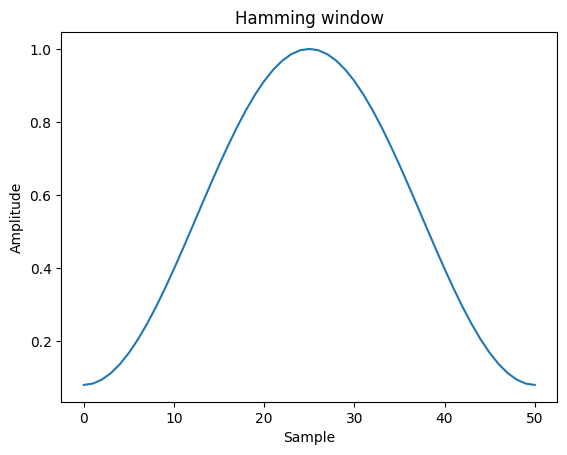

In [15]:
import matplotlib.pyplot as plt
from numpy.fft import fft, fftshift
window = np.hamming(51)
plt.plot(window)
plt.title("Hamming window")
plt.ylabel("Amplitude")
plt.xlabel("Sample")
plt.show()

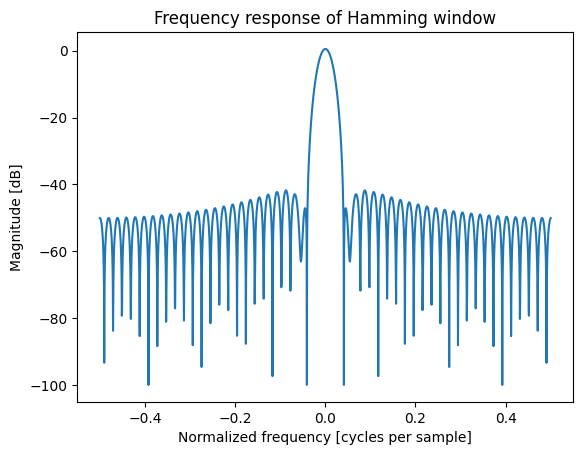

In [16]:
plt.figure()
A = fft(window, 2048) / 25.5
mag = np.abs(fftshift(A))
freq = np.linspace(-0.5, 0.5, len(A))
response = 20 * np.log10(mag)
response = np.clip(response, -100, 100)
plt.plot(freq, response)
plt.title("Frequency response of Hamming window")
plt.ylabel("Magnitude [dB]")
plt.xlabel("Normalized frequency [cycles per sample]")
plt.axis('tight')
plt.show()

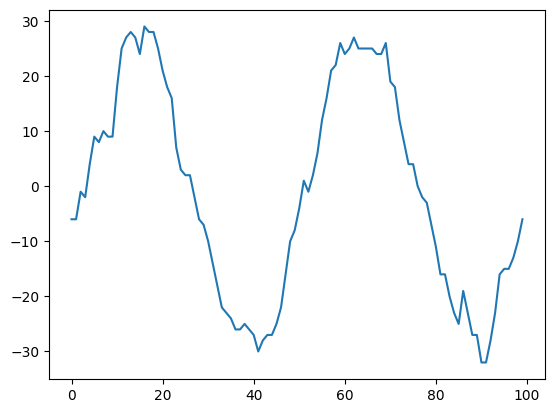

In [30]:
plt.plot(segmented_arrays[150])

In [25]:
import numpy as np

def hamming_window(length):
    return 0.54 - 0.46 * np.cos(2 * np.pi * np.arange(length) / (length - 1))

window_size = len(segmented_arrays[150])
hamming_window = hamming_window(window_size)
windowed_signal = segmented_arrays[150] * hamming_window


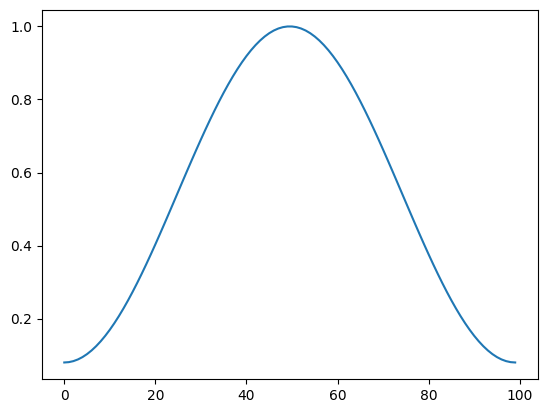

In [20]:
plt.plot(hamming_window)

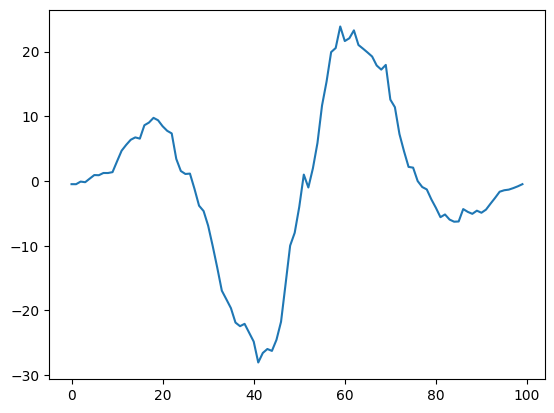

In [26]:
plt.plot(windowed_signal)

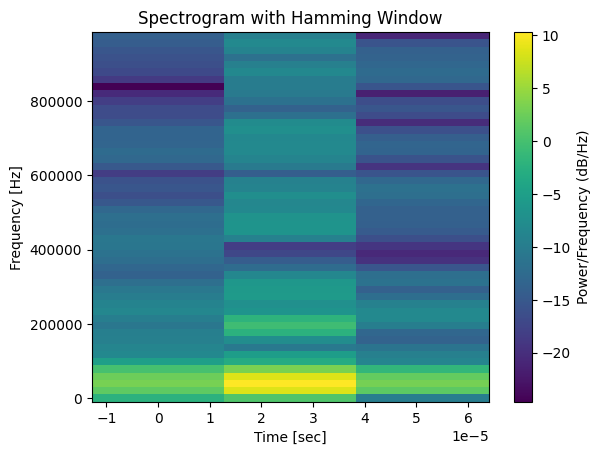

In [27]:
from scipy.signal import stft
import matplotlib.pyplot as plt

# Assuming 'fs' is the sampling frequency of your signal
fs = 1953125  # Replace with your actual sampling frequency

# Parameters for STFT
nperseg = 100  # Number of samples per segment
noverlap = 50  # Number of overlapping samples

frequencies, times, spectrogram = stft(windowed_signal, fs=fs, nperseg=nperseg, noverlap=noverlap)

# Visualize the spectrogram
plt.pcolormesh(times, frequencies, 10 * np.log10(np.abs(spectrogram)))
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram with Hamming Window')
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.show()


In [28]:
frequencies

array([     0.  ,  19531.25,  39062.5 ,  58593.75,  78125.  ,  97656.25,
       117187.5 , 136718.75, 156250.  , 175781.25, 195312.5 , 214843.75,
       234375.  , 253906.25, 273437.5 , 292968.75, 312500.  , 332031.25,
       351562.5 , 371093.75, 390625.  , 410156.25, 429687.5 , 449218.75,
       468750.  , 488281.25, 507812.5 , 527343.75, 546875.  , 566406.25,
       585937.5 , 605468.75, 625000.  , 644531.25, 664062.5 , 683593.75,
       703125.  , 722656.25, 742187.5 , 761718.75, 781250.  , 800781.25,
       820312.5 , 839843.75, 859375.  , 878906.25, 898437.5 , 917968.75,
       937500.  , 957031.25, 976562.5 ])

In [37]:
# Magnitude of the spectrogram
magnitude_spectrogram = np.abs(spectrogram)

# Phase of the spectrogram
phase_spectrogram = np.angle(spectrogram)

In [40]:
type(spectrogram)

numpy.ndarray

In [ ]:
spectrogram.sh

(129, 329)

In [1]:
a = [1,3,4,6]

a[:-1]

[1, 3, 4]

In [18]:
import numpy as np
b = np.array([a,a])

In [19]:
b

array([[1, 3, 4, 6],
       [1, 3, 4, 6]])

In [20]:
b.shape

(2, 4)

In [21]:
b.ndim

2

In [22]:
b.size

8

In [23]:
b.dtype

dtype('int64')

In [24]:
b.data

In [25]:
b

array([[1, 3, 4, 6],
       [1, 3, 4, 6]])

In [32]:
a = np.array([1,1,1,1])
np.multiply(a, b)

array([[1, 3, 4, 6],
       [1, 3, 4, 6]])

In [27]:
a * b

array([[1, 0, 0, 6],
       [1, 0, 0, 6]])

In [28]:
np.multiply(a, b)

array([[1, 0, 0, 6],
       [1, 0, 0, 6]])

In [30]:
np.multiply(b, a)

array([[1, 0, 0, 6],
       [1, 0, 0, 6]])

In [33]:
b

array([[1, 3, 4, 6],
       [1, 3, 4, 6]])

In [39]:
def array_map(x):
    print(x)
    return np.array(list(map(func, x)))

def func(i):
    return i**3


array_map(b)

[[1 3 4 6]
 [1 3 4 6]]


array([[  1,  27,  64, 216],
       [  1,  27,  64, 216]])

In [40]:
np.apply_along_axis(array_map, axis=1, arr=b )

[1 3 4 6]
[1 3 4 6]


array([[  1,  27,  64, 216],
       [  1,  27,  64, 216]])

In [41]:
b = np.array([[1,2,3],[4,5,6]])

In [43]:
b

array([[1, 2, 3],
       [4, 5, 6]])

In [44]:
np.apply_along_axis(array_map, axis=0, arr=b)

[1 4]
[2 5]
[3 6]


array([[  1,   8,  27],
       [ 64, 125, 216]])

In [45]:
np.apply_along_axis(array_map, axis=1, arr=b)

[1 2 3]
[4 5 6]


array([[  1,   8,  27],
       [ 64, 125, 216]])

In [47]:
a = np.array([1,2,3])

In [48]:
a.shape

(3,)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import socket
import struct
import math
from scipy.signal import stft


# Sampling Frequency of original Signal
fs = 1953125

single_segment_size = 100 # Segment size of signal from the raw adc data

# get the signal from redpitaya
buffer_size = 65536
msg_from_client = "-a 1"
bytes_to_send = str.encode(msg_from_client)
server_address_port = ("192.168.128.1", 61231)
# Create a UDP socket at client side
udp_client_socket = socket.socket(family=socket.AF_INET, type=socket.SOCK_DGRAM)
# Send to server using created UDP socket
udp_client_socket.sendto(bytes_to_send, server_address_port)

def get_data_from_sensor(udp_client_socket, buffer_size):
    packet = udp_client_socket.recv(buffer_size)
    print(f"Total Received : {len(packet)} Bytes.")
    header_length = int(struct.unpack('@f', packet[:4])[0])
    ultrasonic_data_length = int(struct.unpack('@f', packet[4:8])[0])
    header_data = []
    for i in struct.iter_unpack('@f', packet[:header_length]):
        header_data.append(i[0])
    print("Header_Length : ", header_length)
    print("Header_Data : ", header_data)
    ultrasonic_data = []
    for i in struct.iter_unpack('@h', packet[header_length:]):
        ultrasonic_data.append(i[0])
    print("Ultrasonic Data Length : ", ultrasonic_data_length)
    # print("Ultrasonic Data : ", ultrasonic_data)
    print(len(ultrasonic_data) + len(header_data))
    print(f"Length of Header : {len(header_data)}")
    print(f"Length of Ultrasonic Data : {len(ultrasonic_data)}")
    # returning the ultrasonic raw adc data from the sensor.
    return ultrasonic_data

def plot_signal(x, y, fig_size = (10, 6), title="ADC Signal", extracted_signal=False):
    # Plot the entire ADC signal
    plt.figure(figsize=fig_size)
    plt.plot(x, y, label=title)
    plt.title(title)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    if extracted_signal:
        plt.show()



def get_arrays_with_overlap_percent(original_array, overlap_percentage=50, single_segment_size=100):
    len_of_org_array = len(original_array)
    overlap_size = overlap_percentage * single_segment_size / 100
    range_of_overlap_array = math.ceil((len_of_org_array - overlap_size) / (single_segment_size - overlap_size))
    overlapped_arrays = list()
    start_index = 0
    for i in range(range_of_overlap_array):
        overlapped_arrays.append(np.array(original_array[start_index:start_index + single_segment_size]))
        start_index = int(start_index +  ((100 - overlap_percentage)* single_segment_size)/100)
    return np.array(overlapped_arrays)


def hamming_window(length):
    return 0.54 - 0.46 * np.cos(2 * np.pi * np.arange(length) / (length - 1))



def get_stft_of_signal(sig_to_stft, fs=1953125, nperseg=100, noverlap=50):
    freq_sig, t_sig, spectrogram_sig = stft(sig_to_stft, fs=fs, nperseg=nperseg, noverlap=noverlap)
    return freq_sig, t_sig, spectrogram_sig


hamming_window_for_seg_signal = hamming_window(single_segment_size)

# Use ginput to interactively select a region
print("Start of the program...")

while True:
    # plt.close()
    raw_adc_data = get_data_from_sensor(udp_client_socket, buffer_size)
    t = [i for i in range(len(raw_adc_data))]
    plot_signal(x=t, y=raw_adc_data)

    #waiting for selecting two points in the graph
    points = plt.ginput(n=2, timeout=0, show_clicks=True)
    # Extract the selected region
    if len(points) == 2:
        start_index, end_index = sorted([int(point[0]) for point in points])
        print(start_index, end_index)
        extracted_signal = raw_adc_data[start_index:end_index]
        xaxis_extracted_sig = [i for i in range(len(extracted_signal))]

        plot_signal(x=xaxis_extracted_sig, y=extracted_signal, fig_size=(8,4), title="Extracted ADC Signal", extracted_signal=True)

        first_empty_arrays = get_arrays_with_overlap_percent(raw_adc_data[:start_index])[:-1]
        mid_return_arrays = get_arrays_with_overlap_percent(raw_adc_data[start_index:end_index])[:-1]
        last_empty_arrays = get_arrays_with_overlap_percent(raw_adc_data[end_index:])[:-1]

        # Elementwise multiplication of the segmented signal to get hammed signal
        hammed_first_empty_arrays = np.multiply(first_empty_arrays, hamming_window_for_seg_signal)
        hammed_mid_return_arrays = np.multiply(mid_return_arrays, hamming_window_for_seg_signal)
        hammed_last_empty_arrays = np.multiply(last_empty_arrays, hamming_window_for_seg_signal)


        # STFT of Hammed Array
        stft_first_empty_arrays = np.apply_along_axis(get_stft_of_signal, axis=1, arr=hammed_first_empty_arrays)
        stft_mid_return_arrays = np.apply_along_axis(get_stft_of_signal, axis=1, arr=hammed_mid_return_arrays)
        stft_last_empty_arrays = np.apply_along_axis(get_stft_of_signal, axis=1, arr=hammed_last_empty_arrays)

        print(stft_first_empty_arrays.shape, stft_mid_return_arrays.shape, stft_last_empty_arrays.shape)

    else:
        print("Selection canceled.")

plt.show()


udp_client_socket.close()

